In [1]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt

In [2]:
data_dir = Path("../logs/final_experiment/crosswords")

In [3]:
list(data_dir.rglob("*.json"))

[PosixPath('../logs/final_experiment/crosswords/B_beta_c/crosswords_B_beta_c_bedrock_B5_E1_budget50_vth0.5_maxstate3_pruneTrue_0_20_20260822_104719_summary.json'),
 PosixPath('../logs/final_experiment/crosswords/B_beta_c/crosswords_B_beta_c_bedrock_B5_E1_budget50_vth0.5_maxstate3_pruneTrue_0_20_20260822_104719.json'),
 PosixPath('../logs/final_experiment/crosswords/C_fixed_k2/crosswords_C_fixed_k2_bedrock_B5_E1_budget50_vth0.5_maxstate3_pruneTrue_0_20_20260821_131200_summary.json'),
 PosixPath('../logs/final_experiment/crosswords/C_fixed_k2/crosswords_C_fixed_k2_bedrock_B5_E1_budget50_vth0.5_maxstate3_pruneTrue_0_20_20260821_131200.json'),
 PosixPath('../logs/final_experiment/crosswords/D_strict_nonparent/crosswords_D_strict_nonparent_bedrock_B5_E1_budget50_vth0.5_maxstate3_pruneTrue_0_20_20260822_221611_summary.json'),
 PosixPath('../logs/final_experiment/crosswords/D_strict_nonparent/crosswords_D_strict_nonparent_bedrock_B5_E1_budget50_vth0.5_maxstate3_pruneTrue_0_20_20260822_221611.

In [4]:
files = {
"B_summary" : Path('/Users/bhoomibhat/Documents/Diss/tree-of-thought-llm/logs/final_experiment/crosswords/B_beta_c/crosswords_B_beta_c_bedrock_B5_E1_budget50_vth0.5_maxstate3_pruneTrue_0_20_20260822_104719_summary.json'),
"B_data" : Path('/Users/bhoomibhat/Documents/Diss/tree-of-thought-llm/logs/final_experiment/crosswords/B_beta_c/crosswords_B_beta_c_bedrock_B5_E1_budget50_vth0.5_maxstate3_pruneTrue_0_20_20260822_104719.json'),
"C_summary" : Path('/Users/bhoomibhat/Documents/Diss/tree-of-thought-llm/logs/final_experiment/crosswords/C_fixed_k2/crosswords_C_fixed_k2_bedrock_B5_E1_budget50_vth0.5_maxstate3_pruneTrue_0_20_20260821_131200_summary.json'),
"C_data" : Path('/Users/bhoomibhat/Documents/Diss/tree-of-thought-llm/logs/final_experiment/crosswords/C_fixed_k2/crosswords_C_fixed_k2_bedrock_B5_E1_budget50_vth0.5_maxstate3_pruneTrue_0_20_20260821_131200.json'),
"D_summary" : Path('/Users/bhoomibhat/Documents/Diss/tree-of-thought-llm/logs/final_experiment/crosswords/D_strict_nonparent/crosswords_D_strict_nonparent_bedrock_B5_E1_budget50_vth0.5_maxstate3_pruneTrue_0_20_20260822_221611_summary.json'),
"D_data": Path('/Users/bhoomibhat/Documents/Diss/tree-of-thought-llm/logs/final_experiment/crosswords/D_strict_nonparent/crosswords_D_strict_nonparent_bedrock_B5_E1_budget50_vth0.5_maxstate3_pruneTrue_0_20_20260822_221611.json'),
"A_data" : Path('/Users/bhoomibhat/Documents/Diss/tree-of-thought-llm/logs/final_experiment/crosswords/A_parent/crosswords_A_parent_bedrock_B5_E1_budget50_vth0.5_maxstate3_pruneTrue_0_20_20260820_120255.json'),
"A_summary" : Path('/Users/bhoomibhat/Documents/Diss/tree-of-thought-llm/logs/final_experiment/crosswords/A_parent/crosswords_A_parent_bedrock_B5_E1_budget50_vth0.5_maxstate3_pruneTrue_0_20_20260820_120255_summary.json')
}

In [5]:
with open(files["A_data"], "r") as f:
    data_A = json.load(f)

with open(files["B_data"], "r") as f:
    data_B = json.load(f)

with open(files["C_data"], "r") as f:
    data_C = json.load(f)

with open(files["D_data"], "r") as f:
    data_D = json.load(f)

with open(files["A_summary"], "r") as f:
    summary_A = json.load(f)

with open(files["B_summary"], "r") as f:
    summary_B = json.load(f)

with open(files["C_summary"], "r") as f:
    summary_C = json.load(f)

with open(files["D_summary"], "r") as f:
    summary_D = json.load(f)

In [6]:
#validate crossward data

print("A:", len(data_A))
print("B:", len(data_B))
print("C:", len(data_C))
print("D:", len(data_D))

A: 20
B: 20
C: 20
D: 20


FINAL ANALYSIS

In [7]:
import pandas as pd

def extract_puzzle_row(r, condition):
    """One row per puzzle. Scores come from infos[0] rather than the
    companion summary file, since infos[0] correctly records 0.0 for puzzles
    where the search explored zero nodes, while the summary file
    mis-records those same puzzles as null."""
    info = (r.get("infos") or [{}])[0]
    evaluated = r["candidates_evaluated"]
    pruned = r["candidates_pruned"]

    return {
        "puzzle_id":              r["idx"],
        "condition":              condition,
        "r_game":                 bool(info.get("r_game")),
        "r_word":                 info.get("r_word"),
        "r_letter":               info.get("r_letter"),
        "nodes_explored":         r["nodes_explored"],
        "candidates_evaluated":   evaluated,
        "candidates_pruned":      pruned,
        "pruning_rate":           (pruned / evaluated) if evaluated else None,
        "num_backtracks_raw":     r["num_backtracks_raw"],
        "num_logical_backtracks": r["num_logical_backtracks"],
        "mean_jump_size":         r["mean_jump_size"],
        "pct_jumps_gt1":          r["pct_jumps_gt1"],
        "beta_calls":             r["beta_calls"],
        "num_cascaded_calls":     r["num_cascaded_calls"],
        "num_unrecoverable":      r["num_unrecoverable"],
    }

df_cw_metrics = pd.concat(
    [
        pd.DataFrame([extract_puzzle_row(r, "A") for r in data_A]),
        pd.DataFrame([extract_puzzle_row(r, "B") for r in data_B]),
        pd.DataFrame([extract_puzzle_row(r, "C") for r in data_C]),
        pd.DataFrame([extract_puzzle_row(r, "D") for r in data_D]),
    ],
    ignore_index=True
)

df_cw_metrics.groupby("condition").size()  # sanity check: should be 20 for each of A/B/C/D


condition
A    20
B    20
C    20
D    20
dtype: int64

In [8]:
# Outcomes table

outcomes_table = (
    df_cw_metrics.groupby("condition")
    .agg(
        n_puzzles       = ("puzzle_id", "count"),
        exact_solves    = ("r_game", "sum"),
        mean_r_word     = ("r_word", "mean"),
        mean_r_letter   = ("r_letter", "mean"),
    )
    .reindex(["A", "B", "C", "D"])
)
outcomes_table["exact_solve_rate_%"] = (outcomes_table["exact_solves"] / outcomes_table["n_puzzles"] * 100).round(1)
outcomes_table = outcomes_table[["exact_solves", "exact_solve_rate_%", "mean_r_word", "mean_r_letter"]].round(3)

print("=== Outcomes ===")
outcomes_table


=== Outcomes ===


,exact_solves,exact_solve_rate_%,mean_r_word,mean_r_letter
condition,,,,
A,1,5.0,0.355,0.518
B,0,0.0,0.390,0.604
C,1,5.0,0.240,0.388
D,0,0.0,0.300,0.468


In [9]:
# Search behaviour table

search_behaviour_table = (
    df_cw_metrics.groupby("condition")
    .agg(
        mean_nodes_explored        = ("nodes_explored", "mean"),
        mean_candidates_evaluated  = ("candidates_evaluated", "mean"),
        mean_candidates_pruned     = ("candidates_pruned", "mean"),
        mean_pruning_rate          = ("pruning_rate", "mean"),  # puzzles with 0 evaluated are excluded automatically
    )
    .reindex(["A", "B", "C", "D"])
    .round(3)
)

print("=== Search behaviour ===")
search_behaviour_table


=== Search behaviour ===


,mean_nodes_explored,mean_candidates_evaluated,mean_candidates_pruned,mean_pruning_rate
condition,,,,
A,32.7,90.50,57.80,0.648
B,28.1,110.55,82.45,0.739
C,17.4,81.20,63.80,0.785
D,14.5,79.55,65.05,0.756


In [11]:
def event_level_jump_stats(records, condition):
    """Mean jump size computed over every individual backtrack event
    in this condition, pooled across all puzzles -- not averaged per puzzle
    first. This avoids diluting the average with puzzles that never
    backtracked, which is what happened with the existing per-puzzle
    'mean_jump_size' field."""
    all_jumps = []
    for r in records:
        for b in r.get("backtracks", []):
            if b.get("jump") is not None:
                all_jumps.append(b["jump"])
    n_events = len(all_jumps)
    if n_events == 0:
        return {"condition": condition, "n_events": 0, "mean_jump": None, "median_jump": None,
                "pct_jumps_gt1": None}
    non_degenerate = sum(1 for j in all_jumps if j > 1)
    return {
        "condition": condition,
        "n_events": n_events,
        "mean_jump": sum(all_jumps) / n_events,
        "pct_jumps_gt1": 100 * non_degenerate / n_events,
    }

import pandas as pd
event_jump_summary_crosswords = pd.DataFrame([
    event_level_jump_stats(data_A, "A"),
    event_level_jump_stats(data_B, "B"),
    event_level_jump_stats(data_C, "C"),
    event_level_jump_stats(data_D, "D"),
]).set_index("condition").round(3)

event_jump_summary_crosswords


,n_events,mean_jump,pct_jumps_gt1
condition,,,
A,654,1.000,0.000
B,371,1.482,38.005
C,180,1.922,92.222
D,147,1.973,74.830


In [12]:
def event_level_jump_stats(records, condition):
    """
    Jump-size statistics computed over every individual backtrack event in
    this condition, pooled across all puzzles
    """
    all_events = []
    for r in records:
        for b in r.get("backtracks", []):
            if b.get("jump") is not None:
                all_events.append(b)

    n_events = len(all_events)
    if n_events == 0:
        return {
            "condition": condition, "n_events": 0, "mean_jump": None, "median_jump": None,
            "pct_jumps_gt1": None, "n_degenerate": 0,
            "n_degenerate_at_depth1": 0, "n_degenerate_at_deeper": 0,
        }

    jumps = [b["jump"] for b in all_events]
    non_degenerate = [j for j in jumps if j > 1]
    degenerate_events = [b for b in all_events if b["jump"] == 1]
    degenerate_at_depth1 = sum(1 for b in degenerate_events if b.get("from_depth") == 1)
    degenerate_at_deeper = sum(1 for b in degenerate_events if b.get("from_depth", 0) > 1)

    return {
        "condition": condition,
        "n_events": n_events,
        "mean_jump": sum(jumps) / n_events,
        "pct_jumps_gt1": 100 * len(non_degenerate) / n_events,
        "n_degenerate": len(degenerate_events),
        "n_degenerate_at_depth1": degenerate_at_depth1,
        "n_degenerate_at_deeper": degenerate_at_deeper,
    }

import pandas as pd

event_jump_summary = pd.DataFrame([
    event_level_jump_stats(data_A, "A"),
    event_level_jump_stats(data_B, "B"),
    event_level_jump_stats(data_C, "C"),
    event_level_jump_stats(data_D, "D"),
]).set_index("condition").round(2)

event_jump_summary


,n_events,mean_jump,pct_jumps_gt1,n_degenerate,n_degenerate_at_depth1,n_degenerate_at_deeper
condition,,,,,,
A,654,1.00,0.00,654,32,622
B,371,1.48,38.01,224,18,206
C,180,1.92,92.22,14,14,0
D,147,1.97,74.83,17,17,0


In [ ]:
import pandas as pd

def extract_backtrack_events_cw(records, condition):
    """One row per backtrack event, crossword schema (rejected_action instead
    of rejected_proposal, from_depth derived from board_history), using the
    same event fields as Game24's dfs.py, checked against dfs_crossward.py."""
    rows = []
    for r in records:
        for event in r.get("backtracks", []):
            rows.append({
                "puzzle_id":                    r["idx"],
                "condition":                    condition,
                "from_depth":                   event.get("from_depth"),
                "to_depth":                     event.get("to_depth"),
                "jump":                         event.get("jump"),
                "degenerate":                   event.get("degenerate"),
                "beta_model_call":              event.get("beta_model_call", False),
                "beta_parse_method":            event.get("beta_parse_method"),
                "cascade":                      event.get("cascade", False),
                "reason":                       event.get("reason"),
                # Condition D bookkeeping only, absent for B events
                "fallback_to_root":             event.get("fallback_to_root"),
                "model_unrecoverable":          event.get("model_unrecoverable"),
                "invalid_target":               event.get("invalid_target"),
                "fallback_to_deepest_nonparent": event.get("fallback_to_deepest_nonparent"),
            })
    return pd.DataFrame(rows)

cw_events_B = extract_backtrack_events_cw(data_B, "B")
cw_events_D = extract_backtrack_events_cw(data_D, "D")
cw_events_all = pd.concat([cw_events_B, cw_events_D], ignore_index=True)


In [ ]:
# RQ1 (crosswords): beta(c) event categorisation, B vs D
#
# Two things are checked separately: whether the model gave a parseable,
# structured answer at all, and whether the parsed target actually reached
# beyond the parent (jump >= 2). A well-formed answer can still just repeat
# the parent (jump == 1) or, rarely, the failed node itself (jump == 0).

cw_model_events = cw_events_all[cw_events_all["beta_model_call"] == True]

def summarize_beta_cw(cond):
    all_ev = cw_events_all[cw_events_all["condition"] == cond]
    mod_ev = cw_model_events[cw_model_events["condition"] == cond]
    jump_counts = mod_ev["jump"].value_counts()
    n_model = len(mod_ev)

    return {
        "total_backtrack_events":        len(all_ev),
        "model_calls":                   n_model,
        "parseable_responses (structured or fallback_last_number)":
            int(mod_ev["beta_parse_method"].isin(["structured", "fallback_last_number"]).sum()),
        "parent_equivalent_jumps (jump=1)":  int(jump_counts.get(1, 0)),
        "genuine_nonparent_jumps (jump>=2)": int(jump_counts[jump_counts.index >= 2].sum()) if n_model else 0,
        "anomalous_jump_eq_0":               int(jump_counts.get(0, 0)),
        "cascades":                          int(mod_ev["cascade"].sum()),
        # Present only for D, always 0 for B since B never uses this path
        "deterministic_root_fallback (no model call, D only)": int(all_ev["fallback_to_root"].fillna(False).sum()),
        "model_unrecoverable_response (D only)":               int(mod_ev["model_unrecoverable"].fillna(False).sum()),
        "model_invalid_target (D only)":                       int(mod_ev["invalid_target"].fillna(False).sum()),
        "fallback_to_deepest_nonparent_used (D only)":         int(mod_ev["fallback_to_deepest_nonparent"].fillna(False).sum()),
    }

cw_beta_behaviour_summary = pd.DataFrame(
    {cond: summarize_beta_cw(cond) for cond in ["B", "D"]}
)

cw_beta_behaviour_summary


In [ ]:
# Rates computed from the counts already established above

for cond in ["B", "D"]:
    n_model = cw_beta_behaviour_summary.loc["model_calls", cond]
    parent_eq = cw_beta_behaviour_summary.loc["parent_equivalent_jumps (jump=1)", cond]
    genuine   = cw_beta_behaviour_summary.loc["genuine_nonparent_jumps (jump>=2)", cond]
    parseable = cw_beta_behaviour_summary.loc["parseable_responses (structured or fallback_last_number)", cond]

    print(f"--- Condition {cond} ---")
    print(f"Response-format reliability: {parseable}/{n_model} = {100*parseable/n_model:.1f}% parseable")
    print(f"Of parseable responses, degenerate to parent: {parent_eq}/{n_model} = {100*parent_eq/n_model:.1f}%")
    print(f"Of parseable responses, genuine non-parent jump: {genuine}/{n_model} = {100*genuine/n_model:.1f}%")
    print()


In [14]:
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, wilcoxon, rankdata
from statsmodels.stats.multitest import multipletests
from itertools import combinations

conditions = ["A", "B", "C", "D"]

def rank_biserial(x, y):
    """Matched-pairs rank-biserial correlation for Wilcoxon signed-rank:
    (sum of positive-difference ranks - sum of negative-difference ranks)
    / total rank sum. Ties (diff == 0) are dropped before ranking."""
    diff = np.array(x) - np.array(y)
    diff = diff[diff != 0]
    if len(diff) == 0:
        return 0.0
    ranks = rankdata(np.abs(diff))
    pos = ranks[diff > 0].sum()
    neg = ranks[diff < 0].sum()
    return (pos - neg) / (pos + neg)

def analyze_outcome_metric(metric_name, df):
    print(f"\n{'='*60}\nRQ2 analysis: {metric_name}\n{'='*60}")

    descriptives = (
        df.groupby("condition")[metric_name]
        .agg(["mean", "median", "std", "min", "max"])
        .reindex(conditions)
        .round(3)
    )
    print("\nDescriptive statistics:")
    print(descriptives)

    wide = df.pivot(index="puzzle_id", columns="condition", values=metric_name)[conditions]
    assert wide.isna().sum().sum() == 0, f"{metric_name} has missing values across conditions"

    friedman_result = friedmanchisquare(*[wide[c] for c in conditions])
    print(f"\nFriedman omnibus: chi2={friedman_result.statistic:.3f}, p={friedman_result.pvalue:.4f}")

    result = {
        "metric": metric_name,
        "descriptives": descriptives,
        "friedman_chi2": friedman_result.statistic,
        "friedman_p": friedman_result.pvalue,
        "pairwise": None,
    }

    if friedman_result.pvalue >= 0.05:
        print("Omnibus not significant — no pairwise post-hoc tests run (pre-registered decision).")
        return result

    pairwise_rows = []
    for c1, c2 in combinations(conditions, 2):
        stat, p = wilcoxon(wide[c1], wide[c2])
        r = rank_biserial(wide[c1], wide[c2])
        pairwise_rows.append({
            "comparison":     f"{c1} vs {c2}",
            "median_diff":    (wide[c1] - wide[c2]).median(),
            "W_statistic":    stat,
            "p_value":        p,
            "rank_biserial":  r,
        })

    pairwise_df = pd.DataFrame(pairwise_rows)
    pairwise_df["p_holm"] = multipletests(pairwise_df["p_value"], method="holm")[1]
    pairwise_df["significant"] = pairwise_df["p_holm"] < 0.05
    pairwise_df = pairwise_df.sort_values("p_holm").reset_index(drop=True)

    print("\nPairwise Wilcoxon, Holm-corrected:")
    print(pairwise_df.round(4))

    result["pairwise"] = pairwise_df
    return result


In [ ]:
# Primary outcome 
rq2_r_word_result = analyze_outcome_metric("r_word", df_cw_metrics)



RQ2 analysis: r_word

Descriptive statistics:
            mean  median    std  min  max
condition                                
A          0.355     0.3  0.328  0.0  1.0
B          0.390     0.4  0.261  0.0  0.8
C          0.240     0.2  0.266  0.0  1.0
D          0.300     0.3  0.258  0.0  0.7

Friedman omnibus: chi2=5.847, p=0.1193
Omnibus not significant — no pairwise post-hoc tests run (pre-registered decision).


In [16]:
# --- Secondary outcome ---
rq2_r_letter_result = analyze_outcome_metric("r_letter", df_cw_metrics)



RQ2 analysis: r_letter

Descriptive statistics:
            mean  median    std  min   max
condition                                 
A          0.518    0.60  0.395  0.0  1.00
B          0.604    0.68  0.317  0.0  0.96
C          0.388    0.44  0.353  0.0  1.00
D          0.468    0.52  0.337  0.0  0.92

Friedman omnibus: chi2=8.158, p=0.0429

Pairwise Wilcoxon, Holm-corrected:
  comparison  median_diff  W_statistic  p_value  rank_biserial  p_holm  \
0     B vs C         0.06         24.5   0.0243         0.6397  0.1455   
1     B vs D         0.04         25.0   0.0468         0.5833  0.2339   
2     A vs C         0.04         36.0   0.1727         0.4000  0.6907   
3     A vs D         0.04         40.5   0.2679         0.3250  0.8036   
4     A vs B        -0.04         68.5   0.4586        -0.1988  0.9171   
5     C vs D         0.00         65.0   0.5859        -0.1503  0.9171   

   significant  
0        False  
1        False  
2        False  
3        False  
4        Fals

In [ ]:
# r_game is checked here, not assumed. The significance test is only skipped
# if every condition genuinely has zero exact solves; otherwise the real
# summary is printed instead.

r_game_summary = (
    df_cw_metrics.groupby("condition")["r_game"]
    .agg(exact_solves="sum", n_puzzles="count")
    .reindex(conditions)
)
r_game_summary["exact_solve_rate_%"] = (
    r_game_summary["exact_solves"] / r_game_summary["n_puzzles"] * 100
).round(1)

print(r_game_summary)

if (r_game_summary["exact_solves"] == 0).all():
    print(
        "\nNo puzzle achieved an exact full-board solution under any of the four "
        "conditions. Consequently, r_game provides no discrimination between "
        "conditions for this experiment and is not used as the basis for "
        "comparing Crossword performance."
    )
else:
    print("\nWARNING: r_game is not uniformly zero — the significance-test skip above no longer applies.")


In [18]:
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, wilcoxon, rankdata
from statsmodels.stats.multitest import multipletests
from itertools import combinations

conditions = ["A", "B", "C", "D"]

def rank_biserial(x, y):
    diff = np.array(x) - np.array(y)
    diff = diff[diff != 0]
    if len(diff) == 0:
        return 0.0
    ranks = rankdata(np.abs(diff))
    pos = ranks[diff > 0].sum()
    neg = ranks[diff < 0].sum()
    return (pos - neg) / (pos + neg)

def analyze_search_metric(metric_name, df):
    print(f"\n{'='*60}\nRQ3 analysis: {metric_name}\n{'='*60}")

    descriptives = (
        df.groupby("condition")[metric_name]
        .agg(["mean", "median", "std", "min", "max"])
        .reindex(conditions)
        .round(3)
    )
    print("\nDescriptive statistics (all puzzles):")
    print(descriptives)

    wide = df.pivot(index="puzzle_id", columns="condition", values=metric_name)[conditions]

    n_before = len(wide)
    wide_complete = wide.dropna()
    n_after = len(wide_complete)
    if n_after < n_before:
        print(f"\nNote: {n_before - n_after} of {n_before} puzzles excluded from the paired test "
              f"— {metric_name} is undefined for at least one condition on those puzzles "
              f"(e.g. 0 candidates evaluated -> pruning_rate has no denominator).")

    friedman_result = friedmanchisquare(*[wide_complete[c] for c in conditions])
    print(f"\nFriedman omnibus (n={n_after} paired puzzles): "
          f"chi2={friedman_result.statistic:.3f}, p={friedman_result.pvalue:.4f}")

    result = {
        "metric": metric_name,
        "n_paired": n_after,
        "friedman_chi2": friedman_result.statistic,
        "friedman_p": friedman_result.pvalue,
        "pairwise": None,
    }

    if friedman_result.pvalue >= 0.05:
        print("Omnibus not significant — no pairwise post-hoc tests run.")
        return result

    pairwise_rows = []
    for c1, c2 in combinations(conditions, 2):
        stat, p = wilcoxon(wide_complete[c1], wide_complete[c2])
        r = rank_biserial(wide_complete[c1], wide_complete[c2])
        pairwise_rows.append({
            "comparison":    f"{c1} vs {c2}",
            "median_diff":   (wide_complete[c1] - wide_complete[c2]).median(),
            "W_statistic":   stat,
            "p_value":       p,
            "rank_biserial": r,
        })

    pairwise_df = pd.DataFrame(pairwise_rows)
    pairwise_df["p_holm"] = multipletests(pairwise_df["p_value"], method="holm")[1]
    pairwise_df["significant"] = pairwise_df["p_holm"] < 0.05
    pairwise_df = pairwise_df.sort_values("p_holm").reset_index(drop=True)

    print("\nPairwise Wilcoxon, Holm-corrected:")
    print(pairwise_df.round(4))

    result["pairwise"] = pairwise_df
    return result


In [19]:
rq3_nodes_result      = analyze_search_metric("nodes_explored", df_cw_metrics)



RQ3 analysis: nodes_explored

Descriptive statistics (all puzzles):
           mean  median     std  min  max
condition                                
A          32.7    50.0  22.914    0   50
B          28.1    23.0  18.923    0   50
C          17.4    12.5  18.262    0   50
D          14.5     9.0  15.018    0   45

Friedman omnibus (n=20 paired puzzles): chi2=17.912, p=0.0005

Pairwise Wilcoxon, Holm-corrected:
  comparison  median_diff  W_statistic  p_value  rank_biserial  p_holm  \
0     A vs D         14.5         11.5   0.0021         0.8497  0.0125   
1     B vs D         14.0         19.0   0.0022         0.8000  0.0125   
2     A vs C         14.0         14.5   0.0097         0.7583  0.0388   
3     B vs C          6.5         23.5   0.0213         0.6544  0.0640   
4     A vs B          0.0         39.5   0.4139         0.2476  0.4542   
5     C vs D          4.5         51.0   0.2271         0.3333  0.4542   

   significant  
0         True  
1         True  
2         

In [20]:
rq3_evaluated_result  = analyze_search_metric("candidates_evaluated", df_cw_metrics)



RQ3 analysis: candidates_evaluated

Descriptive statistics (all puzzles):
             mean  median     std  min  max
condition                                  
A           90.50   118.5  62.171    0  157
B          110.55    97.0  78.799    0  267
C           81.20    63.5  83.913    0  254
D           79.55    51.0  84.089    0  223

Friedman omnibus (n=20 paired puzzles): chi2=3.874, p=0.2754
Omnibus not significant — no pairwise post-hoc tests run.


In [21]:
rq3_pruned_result     = analyze_search_metric("candidates_pruned", df_cw_metrics)



RQ3 analysis: candidates_pruned

Descriptive statistics (all puzzles):
            mean  median     std  min  max
condition                                 
A          57.80    69.5  40.275    0  107
B          82.45    72.5  61.534    0  217
C          63.80    50.5  66.070    0  205
D          65.05    42.5  69.310    0  188

Friedman omnibus (n=20 paired puzzles): chi2=4.264, p=0.2343
Omnibus not significant — no pairwise post-hoc tests run.


In [22]:
rq3_pruning_rate_result = analyze_search_metric("pruning_rate", df_cw_metrics)



RQ3 analysis: pruning_rate

Descriptive statistics (all puzzles):
            mean  median    std    min    max
condition                                    
A          0.648   0.635  0.075  0.538  0.824
B          0.739   0.741  0.049  0.656  0.814
C          0.785   0.779  0.038  0.722  0.857
D          0.756   0.804  0.205  0.000  0.875

Note: 10 of 20 puzzles excluded from the paired test — pruning_rate is undefined for at least one condition on those puzzles (e.g. 0 candidates evaluated -> pruning_rate has no denominator).

Friedman omnibus (n=10 paired puzzles): chi2=22.320, p=0.0001

Pairwise Wilcoxon, Holm-corrected:
  comparison  median_diff  W_statistic  p_value  rank_biserial  p_holm  \
0     A vs B      -0.1200          0.0   0.0020        -1.0000  0.0117   
1     A vs C      -0.1844          0.0   0.0020        -1.0000  0.0117   
2     A vs D      -0.1899          0.0   0.0020        -1.0000  0.0117   
3     B vs D      -0.0457          1.0   0.0039        -0.9636  0.0117

In [ ]:
# Consolidated RQ3 omnibus summary, one place to read all four results

rq3_summary = pd.DataFrame([
    {"metric": r["metric"], "n_paired": r["n_paired"],
     "friedman_chi2": round(r["friedman_chi2"], 3),
     "friedman_p": round(r["friedman_p"], 4),
     "significant": r["friedman_p"] < 0.05,
     "posthoc_run": r["pairwise"] is not None}
    for r in [rq3_nodes_result, rq3_evaluated_result, rq3_pruned_result, rq3_pruning_rate_result]
])

rq3_summary


In [24]:
rq3_backtracks_raw_result = analyze_search_metric("num_backtracks_raw", df_cw_metrics)



RQ3 analysis: num_backtracks_raw

Descriptive statistics (all puzzles):
            mean  median     std  min  max
condition                                 
A          32.70    50.0  22.914    0   50
B          18.55    16.5  12.407    0   38
C           9.00     7.0   9.313    0   25
D           7.35     5.0   6.115    1   21

Friedman omnibus (n=20 paired puzzles): chi2=18.389, p=0.0004

Pairwise Wilcoxon, Holm-corrected:
  comparison  median_diff  W_statistic  p_value  rank_biserial  p_holm  \
0     B vs D         11.0         13.5   0.0002         0.8714  0.0013   
1     A vs D         34.5         17.0   0.0004         0.8381  0.0020   
2     A vs C         26.0          6.0   0.0008         0.9216  0.0033   
3     B vs C          7.5         15.5   0.0023         0.8187  0.0069   
4     A vs B         17.0         39.0   0.0242         0.5895  0.0484   
5     C vs D          2.0         73.5   0.2611         0.3000  0.2611   

   significant  
0         True  
1         True  


In [25]:
rq3_logical_backtracks_result = analyze_search_metric("num_logical_backtracks", df_cw_metrics)



RQ3 analysis: num_logical_backtracks

Descriptive statistics (all puzzles):
            mean  median     std  min  max
condition                                 
A          32.70    50.0  22.914    0   50
B          15.10    13.5   9.994    0   30
C           9.00     7.0   9.313    0   25
D           7.35     5.0   6.115    1   21

Friedman omnibus (n=20 paired puzzles): chi2=17.513, p=0.0006

Pairwise Wilcoxon, Holm-corrected:
  comparison  median_diff  W_statistic  p_value  rank_biserial  p_holm  \
0     A vs D         34.5         17.0   0.0004         0.8381  0.0024   
1     B vs D          7.5         19.0   0.0006         0.8190  0.0029   
2     A vs C         26.0          6.0   0.0008         0.9216  0.0033   
3     A vs B         23.5         29.5   0.0084         0.6895  0.0251   
4     B vs C          4.0         22.5   0.0185         0.6691  0.0371   
5     C vs D          2.0         73.5   0.2611         0.3000  0.2611   

   significant  
0         True  
1         Tru

In [26]:
rq3_jump_size_result = analyze_search_metric("mean_jump_size", df_cw_metrics)



RQ3 analysis: mean_jump_size

Descriptive statistics (all puzzles):
            mean  median    std  min   max
condition                                 
A          0.750   1.000  0.444  0.0  1.00
B          1.271   1.453  0.563  0.0  1.75
C          1.245   1.885  0.941  0.0  2.00
D          1.414   1.690  0.876  0.0  2.60

Friedman omnibus (n=20 paired puzzles): chi2=15.950, p=0.0012

Pairwise Wilcoxon, Holm-corrected:
  comparison  median_diff  W_statistic  p_value  rank_biserial  p_holm  \
0     A vs D      -0.7321         11.0   0.0032        -0.8382  0.0191   
1     A vs B      -0.5156         29.0   0.0079        -0.6947  0.0395   
2     A vs C      -0.9107         46.0   0.1438        -0.3987  0.5750   
3     B vs D      -0.2205         61.0   0.2859        -0.2865  0.8578   
4     B vs C      -0.2990         75.0   0.6475        -0.1228  1.0000   
5     C vs D       0.0000         64.0   0.5540        -0.1634  1.0000   

   significant  
0         True  
1         True  
2   

In [27]:
rq3_pct_jumps_gt1_result = analyze_search_metric("pct_jumps_gt1", df_cw_metrics)



RQ3 analysis: pct_jumps_gt1

Descriptive statistics (all puzzles):
            mean  median    std  min    max
condition                                  
A          0.000   0.000  0.000  0.0  0.000
B          0.342   0.382  0.175  0.0  0.625
C          0.595   0.885  0.455  0.0  1.000
D          0.543   0.667  0.340  0.0  0.875

Friedman omnibus (n=20 paired puzzles): chi2=28.347, p=0.0000

Pairwise Wilcoxon, Holm-corrected:
  comparison  median_diff  W_statistic  p_value  rank_biserial  p_holm  \
0     A vs B      -0.3820          0.0   0.0003        -1.0000  0.0018   
1     A vs D      -0.6667          0.0   0.0006        -1.0000  0.0032   
2     A vs C      -0.8849          0.0   0.0014        -1.0000  0.0056   
3     B vs C      -0.4360         26.0   0.0096        -0.6959  0.0287   
4     B vs D      -0.2111         31.0   0.0176        -0.6374  0.0352   
5     C vs D       0.1314         42.0   0.1786         0.3824  0.1786   

   significant  
0         True  
1         True  

In [ ]:
# Consolidated backtracking-behaviour omnibus summary

rq3_backtracking_summary = pd.DataFrame([
    {"metric": r["metric"], "n_paired": r["n_paired"],
     "friedman_chi2": round(r["friedman_chi2"], 3),
     "friedman_p": round(r["friedman_p"], 4),
     "significant": r["friedman_p"] < 0.05,
     "posthoc_run": r["pairwise"] is not None}
    for r in [
        rq3_backtracks_raw_result,
        rq3_logical_backtracks_result,
        rq3_jump_size_result,
        rq3_pct_jumps_gt1_result,
    ]
])

rq3_backtracking_summary


In [ ]:
# RQ3 (crosswords): beta-specific implementation behaviour, descriptive only.
beta_specific_metrics = ["beta_calls", "num_cascaded_calls", "num_unrecoverable"]

beta_specific_summary = (
    df_cw_metrics.groupby("condition")[beta_specific_metrics]
    .agg(["sum", "mean"])
    .reindex(conditions)
    .round(2)
)

print("=== beta-specific behaviour: totals and per-puzzle means, A-D ===")
print(beta_specific_summary)


In [ ]:
# Puzzles with at least one occurrence, often clearer than a mean when
# the underlying count is a rare event concentrated in a few puzzles.

at_least_one = (
    df_cw_metrics.groupby("condition")[beta_specific_metrics]
    .apply(lambda g: (g > 0).sum())
    .reindex(conditions)
)
at_least_one.columns = [f"{c}_puzzles_with_ge1" for c in at_least_one.columns]

print("\n=== Number of puzzles (out of 20) with >= 1 occurrence ===")
at_least_one


In [ ]:
# Explicit note on which conditions the mechanism applies to, so a zero
# doesn't get misread later as "A and C were tested and came out at zero."

mechanism_applicability = pd.Series({
    "A": "not applicable, parent-only, no backtrack_fn model call exists",
    "B": "applicable, unconstrained beta(c)",
    "C": "not applicable, fixed k=2, deterministic, no model call",
    "D": "applicable, strict non-parent beta(c)",
})

print("\n=== Mechanism applicability by condition ===")
print(mechanism_applicability)


In [34]:
import seaborn as sns

conditions = ["A", "B", "C", "D"]


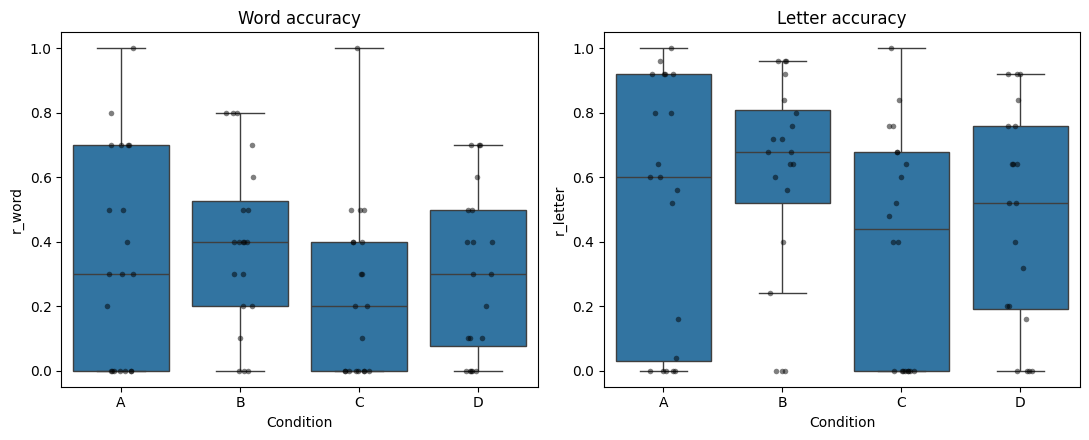

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, metric, title in zip(axes, ["r_word", "r_letter"], ["Word accuracy", "Letter accuracy"]):
    sns.boxplot(data=df_cw_metrics, x="condition", y=metric, order=conditions, showfliers=False, ax=ax)
    sns.stripplot(data=df_cw_metrics, x="condition", y=metric, order=conditions,
                  color="black", alpha=0.5, jitter=0.12, size=4, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Condition")
plt.tight_layout()
plt.savefig("crosswords_accuracy_distributions.png", dpi=150)
plt.show()


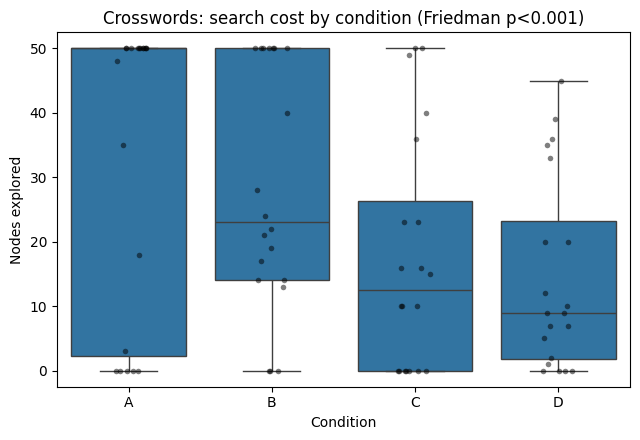

In [38]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
sns.boxplot(data=df_cw_metrics, x="condition", y="nodes_explored", order=conditions, showfliers=False, ax=ax)
sns.stripplot(data=df_cw_metrics, x="condition", y="nodes_explored", order=conditions,
              color="black", alpha=0.5, jitter=0.12, size=4, ax=ax)
ax.set_title("Crosswords: search cost by condition (Friedman p<0.001)")
ax.set_xlabel("Condition")
ax.set_ylabel("Nodes explored")
plt.tight_layout()
plt.savefig("crosswords_nodes_explored_boxplot.png", dpi=150)
plt.show()


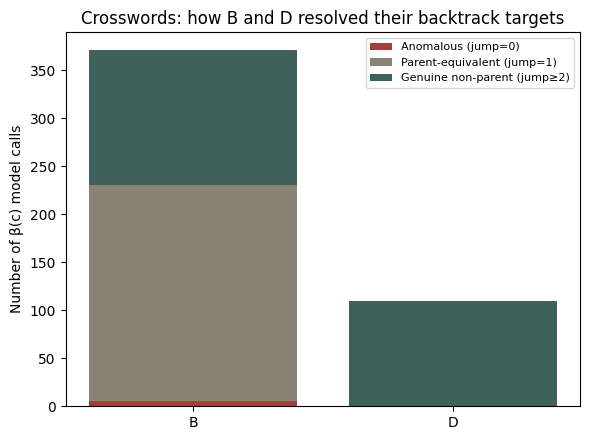

In [39]:
categories_cw = ["Anomalous (jump=0)", "Parent-equivalent (jump=1)", "Genuine non-parent (jump≥2)"]
cat_colors = ["#A23E3E", "#8A8272", "#3E6259"]

def jump_category_counts_cw(cond):
    ev = cw_model_events[cw_model_events["condition"] == cond]
    jumps = ev["jump"]
    return {
        "Anomalous (jump=0)":          (jumps == 0).sum(),
        "Parent-equivalent (jump=1)":  (jumps == 1).sum(),
        "Genuine non-parent (jump≥2)": (jumps >= 2).sum(),
    }

b_counts_cw = jump_category_counts_cw("B")
d_counts_cw = jump_category_counts_cw("D")

fig, ax = plt.subplots(figsize=(6, 4.5))
bottom_b, bottom_d = 0, 0
for cat, color in zip(categories_cw, cat_colors):
    ax.bar("B", b_counts_cw[cat], bottom=bottom_b, color=color, label=cat)
    ax.bar("D", d_counts_cw[cat], bottom=bottom_d, color=color)
    bottom_b += b_counts_cw[cat]
    bottom_d += d_counts_cw[cat]
ax.set_ylabel("Number of β(c) model calls")
ax.set_title("Crosswords: how B and D resolved their backtrack targets")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("crosswords_beta_jump_categories.png", dpi=150)
plt.show()


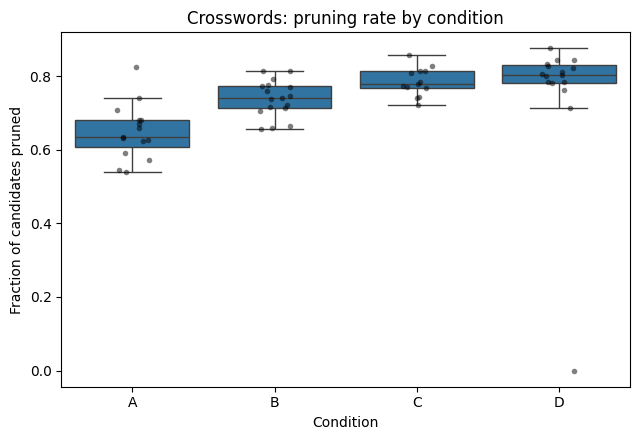

In [40]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
sns.boxplot(data=df_cw_metrics, x="condition", y="pruning_rate", order=conditions, showfliers=False, ax=ax)
sns.stripplot(data=df_cw_metrics, x="condition", y="pruning_rate", order=conditions,
              color="black", alpha=0.5, jitter=0.12, size=4, ax=ax)
ax.set_title("Crosswords: pruning rate by condition")
ax.set_xlabel("Condition")
ax.set_ylabel("Fraction of candidates pruned")
plt.tight_layout()
plt.savefig("crosswords_pruning_rate_boxplot.png", dpi=150)
plt.show()
